# Detección de Fraude Financiero con Machine Learning

Dataset: `financial_fraud_detection_dataset.csv`


# financial_fraud_deteccion_dataset-5

In [1]:
# Importación de librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Carga del dataset
df = pd.read_csv('financial_fraud_detection_dataset.csv')
df.head()

,transaction_id,timestamp,sender_account,receiver_account,amount,transaction_type,merchant_category,location,device_used,is_fraud,fraud_type,time_since_last_transaction,spending_deviation_score,velocity_score,geo_anomaly_score,payment_channel,ip_address,device_hash
0,T100000,2023-08-22T09:22:43.516168,ACC877572,ACC388389,343.78,withdrawal,utilities,Tokyo,mobile,False,NaN,NaN,-0.21,3,0.22,card,13.101.214.112,D8536477
1,T100001,2023-08-04T01:58:02.606711,ACC895667,ACC944962,419.65,withdrawal,online,Toronto,atm,False,NaN,NaN,-0.14,7,0.96,ACH,172.52.47.194,D2622631
2,T100002,2023-05-12T11:39:33.742963,ACC733052,ACC377370,2773.86,deposit,other,London,pos,False,NaN,NaN,-1.78,20,0.89,card,185.98.35.23,D4823498
3,T100003,2023-10-10T06:04:43.195112,ACC996865,ACC344098,1666.22,deposit,online,Sydney,pos,False,NaN,NaN,-0.60,6,0.37,wire_transfer,107.136.36.87,D9961380
4,T100004,2023-09-24T08:09:02.700162,ACC584714,ACC497887,24.43,transfer,utilities,Toronto,mobile,False,NaN,NaN,0.79,13,0.27,ACH,108.161.108.255,D7637601


In [3]:
df.isna().sum()

,0
transaction_id,0
timestamp,0
sender_account,0
receiver_account,0
amount,0
transaction_type,0
merchant_category,0
location,0
device_used,0
is_fraud,0


In [4]:
df['fraud_type'].value_counts()

,count
fraud_type,
card_not_present,179553


In [5]:
df['time_since_last_transaction'].value_counts()

,count
time_since_last_transaction,
5257.349021,1
-4797.552868,1
3705.738348,1
2158.906433,1
-71.393848,1
...,...
-6596.098540,1
3264.824358,1
-2391.075178,1


In [6]:
df['fraud_type'] = df['fraud_type'].fillna('0')
df['time_since_last_transaction'] = df['time_since_last_transaction'].fillna(0)

In [7]:
df.head(5)

,transaction_id,timestamp,sender_account,receiver_account,amount,transaction_type,merchant_category,location,device_used,is_fraud,fraud_type,time_since_last_transaction,spending_deviation_score,velocity_score,geo_anomaly_score,payment_channel,ip_address,device_hash
0,T100000,2023-08-22T09:22:43.516168,ACC877572,ACC388389,343.78,withdrawal,utilities,Tokyo,mobile,False,0,0.0,-0.21,3,0.22,card,13.101.214.112,D8536477
1,T100001,2023-08-04T01:58:02.606711,ACC895667,ACC944962,419.65,withdrawal,online,Toronto,atm,False,0,0.0,-0.14,7,0.96,ACH,172.52.47.194,D2622631
2,T100002,2023-05-12T11:39:33.742963,ACC733052,ACC377370,2773.86,deposit,other,London,pos,False,0,0.0,-1.78,20,0.89,card,185.98.35.23,D4823498
3,T100003,2023-10-10T06:04:43.195112,ACC996865,ACC344098,1666.22,deposit,online,Sydney,pos,False,0,0.0,-0.60,6,0.37,wire_transfer,107.136.36.87,D9961380
4,T100004,2023-09-24T08:09:02.700162,ACC584714,ACC497887,24.43,transfer,utilities,Toronto,mobile,False,0,0.0,0.79,13,0.27,ACH,108.161.108.255,D7637601


In [8]:
#Exploración básica
print(df.shape)
print(df['is_fraud'].value_counts(normalize=True))

(5000000, 18)
is_fraud
False    0.964089
True     0.035911
Name: proportion, dtype: float64


In [9]:
#Asegurar variable objetivo numérica
if df['is_fraud'].dtype == 'bool':
  df['is_fraud'] = df['is_fraud'].astype(int)

In [10]:
df

,transaction_id,timestamp,sender_account,receiver_account,amount,transaction_type,merchant_category,location,device_used,is_fraud,fraud_type,time_since_last_transaction,spending_deviation_score,velocity_score,geo_anomaly_score,payment_channel,ip_address,device_hash
0,T100000,2023-08-22T09:22:43.516168,ACC877572,ACC388389,343.78,withdrawal,utilities,Tokyo,mobile,0,0,0.000000,-0.21,3,0.22,card,13.101.214.112,D8536477
1,T100001,2023-08-04T01:58:02.606711,ACC895667,ACC944962,419.65,withdrawal,online,Toronto,atm,0,0,0.000000,-0.14,7,0.96,ACH,172.52.47.194,D2622631
2,T100002,2023-05-12T11:39:33.742963,ACC733052,ACC377370,2773.86,deposit,other,London,pos,0,0,0.000000,-1.78,20,0.89,card,185.98.35.23,D4823498
3,T100003,2023-10-10T06:04:43.195112,ACC996865,ACC344098,1666.22,deposit,online,Sydney,pos,0,0,0.000000,-0.60,6,0.37,wire_transfer,107.136.36.87,D9961380
4,T100004,2023-09-24T08:09:02.700162,ACC584714,ACC497887,24.43,transfer,utilities,Toronto,mobile,0,0,0.000000,0.79,13,0.27,ACH,108.161.108.255,D7637601
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4999995,T5099995,2023-11-17T23:20:29.746144,ACC597319,ACC749300,10.87,withdrawal,retail,Toronto,atm,0,0,1416.524233,-0.14,17,0.18,UPI,243.92.38.163,D4439579
4999996,T5099996,2023-09-23T11:23:20.659686,ACC749625,ACC709783,181.40,payment,grocery,Sydney,atm,0,0,999.089702,-1.79,4,0.58,wire_transfer,28.252.18.249,D5029311
4999997,T5099997,2023-11-18T00:52:34.527092,ACC629492,ACC680736,12.54,payment,utilities,New York,mobile,0,0,3871.584025,-0.30,6,0.99,card,111.199.174.121,D6333607
4999998,T5099998,2023-03-25T04:32:13.609837,ACC984720,ACC296935,376.29,deposit,restaurant,Dubai,pos,0,0,-4096.765453,-1.43,5,0.32,wire_transfer,221.110.215.14,D1551203


##Se borran las siguientes variables:

transaction_id

sender_account

receiver_account

ip_address

device_hash

¿Por qué?

❌ Son identificadores únicos
❌ No aportan patrón
❌ Rompen el modelo

In [11]:
df.drop([
    'transaction_id',
    'sender_account',
    'receiver_account',
    'ip_address',
    'device_hash'
], axis=1, inplace=True)

### Se transforma las siguiente variables de 'object' a variables numericas.


In [12]:
df = pd.get_dummies(df, columns=[
    'transaction_type',
    'merchant_category',
    'location',
    'device_used',
    'payment_channel'
], drop_first=True)

In [13]:
# Se borra la variable fraude_type
df = df.drop(columns=['fraud_type'])

###VARIABLE FECHA (timestamp) conversion de object a time

In [14]:
df['timestamp'] = pd.to_datetime(df['timestamp'], format='mixed', errors='coerce')

In [15]:
df['hour'] = df['timestamp'].dt.hour
df['day'] = df['timestamp'].dt.day
df['month'] = df['timestamp'].dt.month

In [16]:
df.drop('timestamp', axis=1, inplace=True)

In [17]:
df.head()

,amount,is_fraud,time_since_last_transaction,spending_deviation_score,velocity_score,geo_anomaly_score,transaction_type_payment,transaction_type_transfer,transaction_type_withdrawal,merchant_category_grocery,...,location_Toronto,device_used_mobile,device_used_pos,device_used_web,payment_channel_UPI,payment_channel_card,payment_channel_wire_transfer,hour,day,month
0,343.78,0,0.0,-0.21,3,0.22,False,False,True,False,...,False,True,False,False,False,True,False,9,22,8
1,419.65,0,0.0,-0.14,7,0.96,False,False,True,False,...,True,False,False,False,False,False,False,1,4,8
2,2773.86,0,0.0,-1.78,20,0.89,False,False,False,False,...,False,False,True,False,False,True,False,11,12,5
3,1666.22,0,0.0,-0.60,6,0.37,False,False,False,False,...,False,False,True,False,False,False,True,6,10,10
4,24.43,0,0.0,0.79,13,0.27,False,True,False,False,...,True,True,False,False,False,False,False,8,24,9


In [18]:
X = df.drop('is_fraud', axis=1)
y = df['is_fraud']

In [19]:
from sklearn.model_selection import train_test_split
X,X_test,y,y_test = train_test_split(X,y,test_size=0.15,stratify=y,random_state=5)
X_train,X_val,y_train,y_val = train_test_split(X,y,stratify=y,random_state=5)

## Correlación de variables numéricas con is_fraud

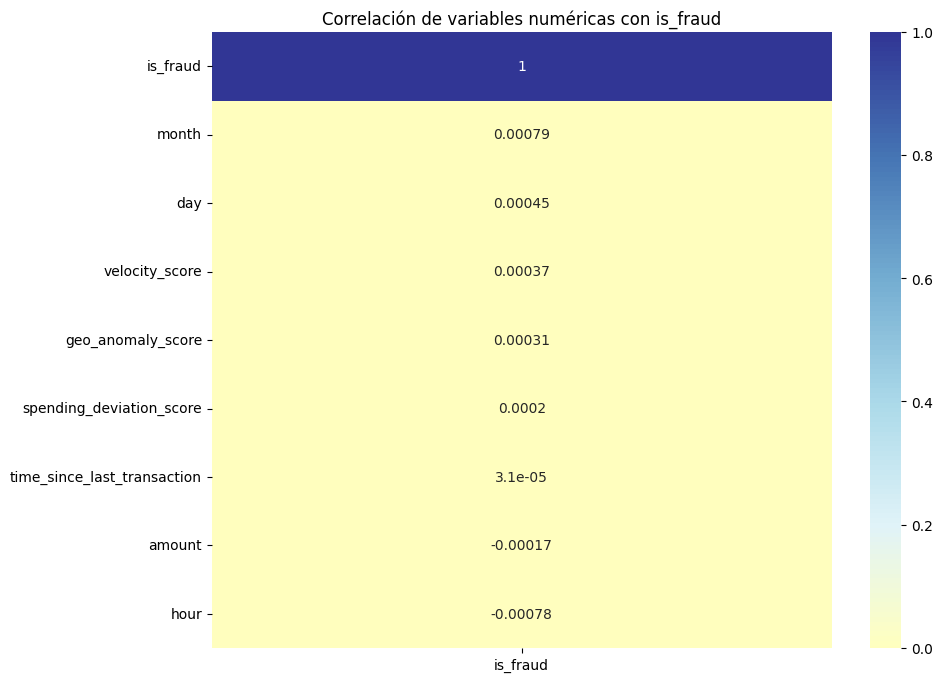

In [20]:
# Asegurar que la variable objetivo sea numérica
df['is_fraud'] = df['is_fraud'].astype(int)

# Seleccionar solo variables numéricas (incluyendo bool por seguridad)
numericas = df.select_dtypes(include=['int64', 'float64', 'int32', 'float32'])

# Verificar que is_fraud esté presente
if 'is_fraud' not in numericas.columns:
    raise ValueError("La columna 'is_fraud' no está en las variables numéricas")

# Calcular matriz de correlación
corr_matrix = numericas.corr()

# Crear heatmap SOLO con correlación hacia is_fraud
plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix[['is_fraud']]
    .sort_values(by='is_fraud', ascending=False),
    annot=True,
    cmap= 'RdYlBu',
    center=0
)

plt.title('Correlación de variables numéricas con is_fraud')
plt.show()
plt.close('all')

## Análisis de correlación

## Matriz de correlación con `is_fraud`

Esta matriz muestra qué tan relacionada está cada variable numérica con la variable objetivo `is_fraud`.

**¿Qué se observa?**

Todas las correlaciones son **extremadamente cercanas a cero**, lo que indica que ninguna variable numérica tiene una relación lineal significativa con el fraude:

| Variable | Correlación | Interpretación |
|---|---|---|
| `velocity_score` | 0.00037 | Casi nula (positiva) |
| `geo_anomaly_score` | 0.00031 | Casi nula (positiva) |
| `spending_deviation_score` | 0.0002 | Casi nula (positiva) |
| `time_since_last_transaction` | 3.1e-05 | Prácticamente cero |
| `amount` | -0.00017 | Casi nula (negativa) |

**¿Qué implica esto?**

- El fraude **no puede predecirse linealmente** a partir de estas variables por separado.
- Esto no significa que las variables sean inútiles; simplemente que las relaciones pueden ser **no lineales o combinadas** (por eso modelos como Random Forest o XGBoost suelen funcionar mejor en detección de fraude).
- También podría indicar un **dataset muy desbalanceado**, donde los casos de fraude son minoría, lo cual comprime las correlaciones hacia cero.

En resumen, esta imagen sugiere que se necesita un enfoque más sofisticado que la regresión lineal simple para detectar fraude.

##Código para Graficar la Importancia de Variables

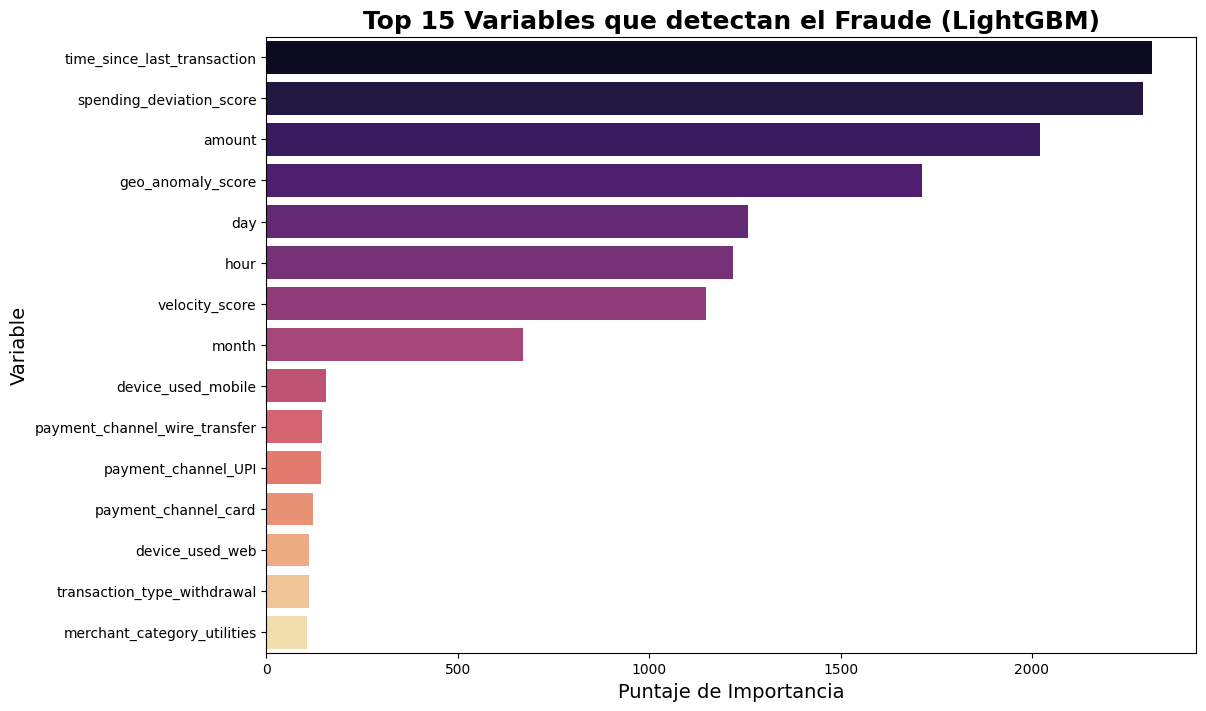

In [21]:
import lightgbm as lgb

# Entrenar modelo SOLO para el gráfico de importancia
modelo_importancia = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=-1,
    random_state=42,
    verbosity=-1
)
modelo_importancia.fit(X_train, y_train)

#Extraer las importancias y graficar
importancias = modelo_importancia.feature_importances_
nombres_columnas = X_train.columns

df_importancia = pd.DataFrame({
    'Variable': nombres_columnas,
    'Importancia': importancias
}).sort_values(by='Importancia', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x='Importancia', y='Variable', data=df_importancia.head(15), palette='magma')
plt.title('Top 15 Variables que detectan el Fraude (LightGBM)', fontsize=18, fontweight='bold')
plt.xlabel('Puntaje de Importancia', fontsize=14)
plt.ylabel('Variable', fontsize=14)
plt.show()
plt.close('all')

##Interpretación de la Importancia de Variables

La importancia de variables nos revela qué factores utiliza el algoritmo para distinguir una transacción legítima de un fraude. En este modelo, observamos que:

Jerarquía de Decisión: No todas las variables aportan igual; usualmente, unas pocas (como el monto o los puntajes de riesgo) concentran la mayor capacidad predictiva.

Patrones de Comportamiento: Si variables como la hora o el tipo de transacción aparecen en el top, el modelo ha detectado "ventanas de oportunidad" que los estafadores suelen explotar.

Optimización: Este gráfico nos permite simplificar el modelo en el futuro, eliminando aquellas variables que no aportan valor (las de barra muy corta) sin perder puntería.

Nota clave: Un modelo que depende de variables lógicas (como el historial del cliente) es más robusto que uno que depende de variables aleatorias. Con esto, validamos que nuestro LightGBM no solo es preciso, sino que tiene sentido común financiero.

 ## Transacciones Legítimas vs. Fraudulentas

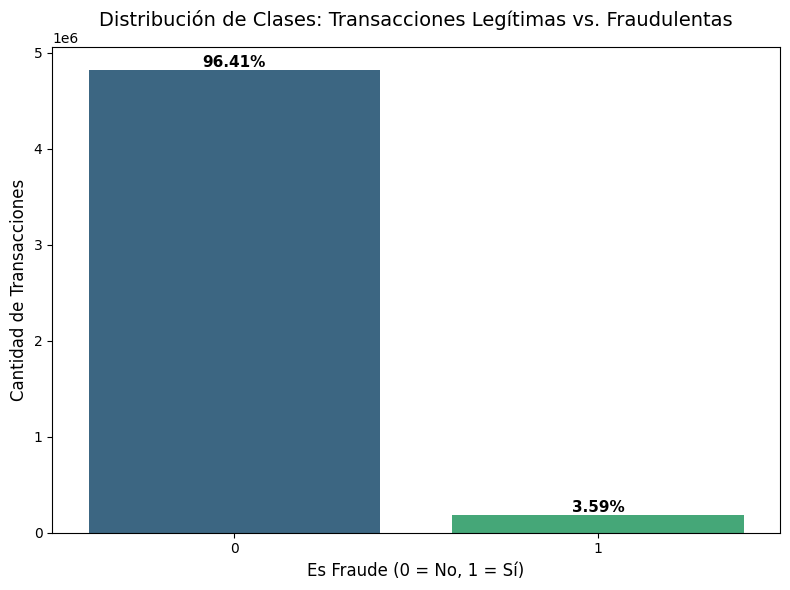

In [22]:
# Crear figura
plt.figure(figsize=(8, 6))

# Generar el gráfico de barras
ax = sns.countplot(data=df, x='is_fraud', palette='viridis')

# Personalizar títulos y etiquetas
plt.title('Distribución de Clases: Transacciones Legítimas vs. Fraudulentas', fontsize=14, pad=15)
plt.xlabel('Es Fraude (0 = No, 1 = Sí)', fontsize=12)
plt.ylabel('Cantidad de Transacciones', fontsize=12)

# Calcular y agregar los porcentajes sobre cada barra
total = len(df)
for p in ax.patches:
    altura = p.get_height()
    porcentaje = f'{100 * altura / total:.2f}%'
    # Posicionar el texto en el centro de la barra y un poco por encima
    ax.annotate(porcentaje,
                (p.get_x() + p.get_width() / 2, altura),
                ha='center',
                va='bottom',
                fontsize=11,
                fontweight='bold')

# Ajustar márgenes y mostrar
plt.tight_layout()
plt.show()
plt.close('all')

## Análisis de Patrones de Fraude por Variables Categóricas

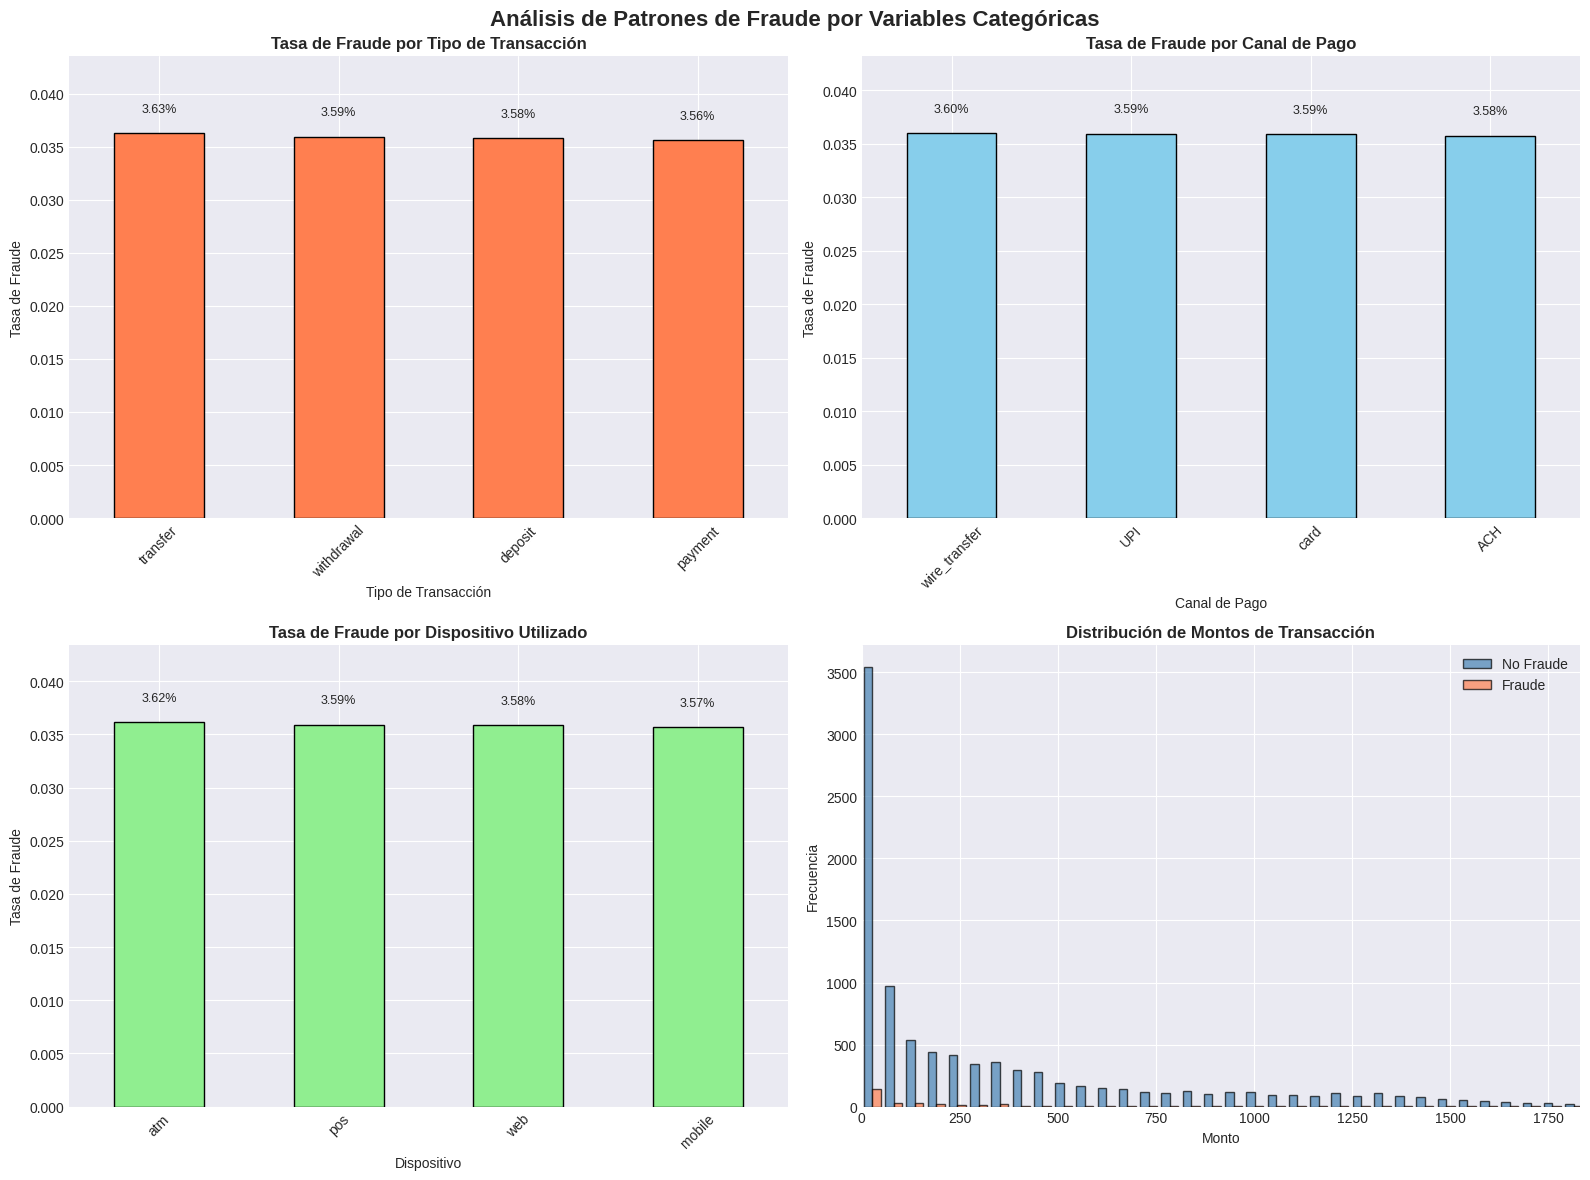

In [23]:
# Recargar datos originales SOLO para visualización
df_original = pd.read_csv('financial_fraud_detection_dataset.csv')

# Aplicar solo las transformaciones necesarias para visualización
df_original['fraud_type'] = df_original['fraud_type'].fillna('0')
df_original['time_since_last_transaction'] = df_original['time_since_last_transaction'].fillna(0)

# Convertir is_fraud a numérico si es necesario
if df_original['is_fraud'].dtype == 'bool':
    df_original['is_fraud'] = df_original['is_fraud'].astype(int)


# Configurar el estilo
plt.style.use('seaborn-v0_8-darkgrid')
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Análisis de Patrones de Fraude por Variables Categóricas', fontsize=16, fontweight='bold')

# 1. Tasa de fraude por tipo de transacción
ax1 = axes[0, 0]
fraud_by_type = df_original.groupby('transaction_type')['is_fraud'].mean().sort_values(ascending=False)
fraud_by_type.plot(kind='bar', ax=ax1, color='coral', edgecolor='black')
ax1.set_title('Tasa de Fraude por Tipo de Transacción', fontsize=12, fontweight='bold')
ax1.set_xlabel('Tipo de Transacción')
ax1.set_ylabel('Tasa de Fraude')
ax1.set_ylim(0, fraud_by_type.max() * 1.2)
ax1.tick_params(axis='x', rotation=45)
for i, v in enumerate(fraud_by_type):
    ax1.text(i, v + 0.002, f'{v:.2%}', ha='center', fontsize=9)

# 2. Tasa de fraude por canal de pago
ax2 = axes[0, 1]
fraud_by_channel = df_original.groupby('payment_channel')['is_fraud'].mean().sort_values(ascending=False)
fraud_by_channel.plot(kind='bar', ax=ax2, color='skyblue', edgecolor='black')
ax2.set_title('Tasa de Fraude por Canal de Pago', fontsize=12, fontweight='bold')
ax2.set_xlabel('Canal de Pago')
ax2.set_ylabel('Tasa de Fraude')
ax2.set_ylim(0, fraud_by_channel.max() * 1.2)
ax2.tick_params(axis='x', rotation=45)
for i, v in enumerate(fraud_by_channel):
    ax2.text(i, v + 0.002, f'{v:.2%}', ha='center', fontsize=9)

# 3. Tasa de fraude por dispositivo utilizado
ax3 = axes[1, 0]
fraud_by_device = df_original.groupby('device_used')['is_fraud'].mean().sort_values(ascending=False)
fraud_by_device.plot(kind='bar', ax=ax3, color='lightgreen', edgecolor='black')
ax3.set_title('Tasa de Fraude por Dispositivo Utilizado', fontsize=12, fontweight='bold')
ax3.set_xlabel('Dispositivo')
ax3.set_ylabel('Tasa de Fraude')
ax3.set_ylim(0, fraud_by_device.max() * 1.2)
ax3.tick_params(axis='x', rotation=45)
for i, v in enumerate(fraud_by_device):
    ax3.text(i, v + 0.002, f'{v:.2%}', ha='center', fontsize=9)

# 4. Distribución de montos de transacción (fraudulentas vs no fraudulentas)
ax4 = axes[1, 1]
# Tomar una muestra para mejor rendimiento visual (10,000 registros)
sample_df = df_original.sample(n=min(10000, len(df_original)), random_state=42)
fraud_sample = sample_df[sample_df['is_fraud'] == 1]['amount']
non_fraud_sample = sample_df[sample_df['is_fraud'] == 0]['amount']

ax4.hist([non_fraud_sample, fraud_sample], bins=50, alpha=0.7,
         label=['No Fraude', 'Fraude'], color=['steelblue', 'coral'], edgecolor='black')
ax4.set_title('Distribución de Montos de Transacción', fontsize=12, fontweight='bold')
ax4.set_xlabel('Monto')
ax4.set_ylabel('Frecuencia')
ax4.legend()
ax4.set_xlim(0, sample_df['amount'].quantile(0.99))

plt.tight_layout()
plt.show()
plt.close('all')

### Comparación de Modelos de Clasificación por Exactitud o Accuracy
#### 1. Random Forest

#### 2. XGBoost

#### 3. LightGBM

In [24]:
from sklearn.ensemble import RandomForestClassifier

modelo_rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    n_jobs=-1,
    class_weight='balanced',
    random_state=5
)

modelo_rf.fit(X_train, y_train)
print(f"Score Random Forest: {modelo_rf.score(X_test, y_test)}")

Score Random Forest: 0.2577853333333333


In [25]:
from xgboost import XGBClassifier

# Definición del modelo optimizado para grandes datos
modelo_xgb = XGBClassifier(
    max_depth=3,
    random_state=5,
    tree_method='hist',
    device="cpu",
    n_estimators=100,
    scale_pos_weight=99
)

modelo_xgb.fit(X_train, y_train)
print(f"Score XGBoost: {modelo_xgb.score(X_test, y_test)}")

Score XGBoost: 0.21912266666666666


In [26]:
from lightgbm import LGBMClassifier

# Definición del modelo
modelo_lgbm = LGBMClassifier(
    max_depth=3,
    random_state=5,
    n_estimators=100,
    learning_rate=0.1,
    is_unbalance=True,
    n_jobs=-1,
    verbosity=-1)

modelo_lgbm.fit(X_train, y_train)
print(f"Score LightGBM: {modelo_lgbm.score(X_test, y_test)}")

Score LightGBM: 0.216824


En estos tres modelos se realizó un balanceo por peso, concepto clave en Machine Learning aplicado a fraude

¿Qué es el balanceo por pesos?

El balanceo por pesos consiste en:

darle más importancia a la clase minoritaria (fraude)
sin cambiar los datos

###Cálculo de accuracy, presición, recall, f1_score

In [27]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd
modelo1 =  RandomForestClassifier(max_depth=10, random_state=5)
modelo2 =  XGBClassifier(max_depth=10, random_state=5)
modelo3 =  LGBMClassifier(max_depth=10, random_state=5, is_unbalance=True)

# Definimos una función para no repetir código
def evaluar_modelo(modelo, nombre, X_entrenamiento, y_entrenamiento, X_prueba, y_prueba):
    # Ajustar el modelo
    modelo.fit(X_entrenamiento, y_entrenamiento)

    # Predecir
    y_pred = modelo.predict(X_prueba)

    # Calcular métricas
    acc = accuracy_score(y_prueba, y_pred)
    prec = precision_score(y_prueba, y_pred)
    rec = recall_score(y_prueba, y_pred)
    f1 = f1_score(y_prueba, y_pred)

    # Imprimir resultados formateados
    print(f"--- Reporte: {nombre} ---")
    print(f"Exactitud (Accuracy):   {acc:.4f}")
    print(f"Precisión (Precision):  {prec:.4f}")
    print(f"Sensibilidad (Recall): {rec:.4f}")
    print(f"F1-Score:               {f1:.4f}")
    print("-" * 30)

    return {"Modelo": nombre, "Accuracy": acc, "Precision": prec, "Recall": rec, "F1": f1}

# Ejecutar la evaluación para cada modelo de forma clara
resultados_lista = []

# Evaluamos uno por uno llamando a la función
resultados_lista.append(evaluar_modelo(modelo_rf, "RandomForestClassifier", X_train, y_train, X_test, y_test))
resultados_lista.append(evaluar_modelo(modelo_xgb, "XGBoost", X_train, y_train, X_test, y_test))
resultados_lista.append(evaluar_modelo(modelo_lgbm, "LightGBM", X_train, y_train, X_test, y_test))

# Crear una tabla resumen automática
df_resumen = pd.DataFrame(resultados_lista)

--- Reporte: RandomForestClassifier ---
Exactitud (Accuracy):   0.2578
Precisión (Precision):  0.0437
Sensibilidad (Recall): 0.9415
F1-Score:               0.0835
------------------------------
--- Reporte: XGBoost ---
Exactitud (Accuracy):   0.2191
Precisión (Precision):  0.0438
Sensibilidad (Recall): 0.9954
F1-Score:               0.0839
------------------------------
--- Reporte: LightGBM ---
Exactitud (Accuracy):   0.2168
Precisión (Precision):  0.0437
Sensibilidad (Recall): 0.9977
F1-Score:               0.0838
------------------------------


##Matriz de Confusion

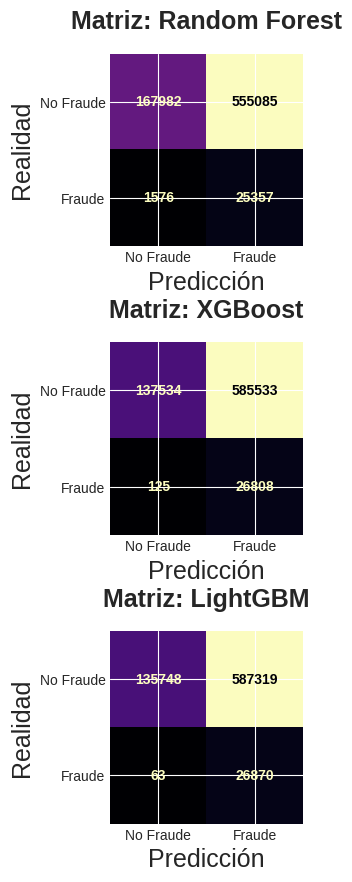

In [28]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Aumentamos drásticamente el alto (30) para que cada matriz tenga su espacio
fig, axes = plt.subplots(3, 1, figsize=(10, 10))

modelos = [
    (modelo_rf, "Random Forest"),
    (modelo_xgb, "XGBoost"),
    (modelo_lgbm, "LightGBM")
]

for i, (modelo, nombre) in enumerate(modelos):
    y_pred = modelo.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    # 2. display_labels más cortos para ganar espacio
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Fraude', 'Fraude'])

    disp.plot(ax=axes[i], cmap='magma', values_format='d', colorbar=False)

    # 4. Títulos y etiquetas más grandes
    axes[i].set_title(f'Matriz: {nombre}', fontsize=18, pad=18, fontweight='bold')
    axes[i].set_xlabel('Predicción', fontsize=18)
    axes[i].set_ylabel('Realidad', fontsize=18)

    # 5. Agrandar los números internos para que sean legibles
    for text in disp.text_.ravel():
        text.set_fontsize(10)
        text.set_fontweight('bold')

# 6. hspace aumenta el espacio vertical entre los tres gráficos
plt.subplots_adjust(hspace=0.5)
plt.show()

###Explicación de las Matrices de Confusión
---
1. La diagonal del éxito (Arriba-Izquierda y Abajo-Derecha)

Estas son las predicciones correctas.

Fondo Negro (Abajo-Derecha): Son los fraudes que el modelo atrapó con éxito. Fíjate que en los tres modelos este número es alto (~25,000 - 26,000), lo cual es excelente.

Fondo Púrpura (Arriba-Izquierda): Son las transacciones normales que el modelo identificó correctamente como "No Fraude".

---
2. El punto crítico: Falsos Negativos (Abajo-Izquierda)

Este es el número más importante en ciberseguridad: fraudes que el modelo dejó pasar.

Random Forest: Dejó pasar 1,576 fraudes. Es un riesgo alto.

XGBoost: Bajó el error a solo 125.

LightGBM: Es el modelo indiscutible con solo 63 fraudes perdidos. Es casi un muro infranqueable para los delincuentes.

---
3. El "Efecto Secundario": Falsos Positivos (Arriba-Derecha - Cuadros Amarillos)

Aquí es donde vemos por qué la precisión es baja. El cuadro amarillo brillante muestra las transacciones legales que el modelo marcó como fraude.

En los tres casos, el número es enorme (alrededor de 587,000).

Significado: El modelo es tan "protector" que está bloqueando a muchísimos clientes honestos. Es como un guardia de seguridad que detiene a todos en la puerta por si acaso uno es un ladrón.

---
Conclusión del Análisis

Tus modelos (especialmente LightGBM) están configurados para "Cero Tolerancia al Riesgo".

Ventaja: Casi no pierdes dinero por robos.

Desventaja: Tu equipo de atención al cliente estará muy ocupado desbloqueando tarjetas de usuarios legítimos que fueron marcados erróneamente.

In [ ]:
import gc

del modelo_rf
gc.collect()

del modelo_xgb
gc.collect()

del modelo_lgbm
gc.collect()


0

##Pasos Finales

In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from imblearn.pipeline import Pipeline as imbpipeline
from imblearn.under_sampling import  RandomUnderSampler
import joblib

In [30]:
modelo1 = LogisticRegression(solver='liblinear', random_state=42)

pipeline = imbpipeline([
    ('undersample',  RandomUnderSampler(random_state=42)),
    ('logistic', modelo1)
])

param_grid = {
    'logistic__C': [0.01, 0.1, 1, 10],
    'logistic__penalty': ['l1', 'l2']
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=5)

X_train = X_train.astype('float32')

grid = GridSearchCV(pipeline, param_grid=param_grid, cv=cv, scoring='recall', n_jobs=1)
grid.fit(X_train, y_train)  # ✅ CORRECCIÓN: usar X_train/y_train, no X/y completo

print("Mejores hiperparámetros:", grid.best_params_)
print("Mejor recall promedio:", grid.best_score_)

Mejores hiperparámetros: {'logistic__C': 0.01, 'logistic__penalty': 'l1'}
Mejor recall promedio: 0.52048224348054


###CORRECCIÓN: el champion se guarda DESPUÉS de comparar modelos,
###no en medio del entrenamiento de Logistic Regression.
###Esta celda se mueve al final, luego del GridSearch de LightGBM.

In [31]:
# ✅ CORRECCIÓN: se redefine modelo_lgbm con parámetros base consistentes.
modelo_lgbm_final = LGBMClassifier(
    max_depth=3,
    random_state=5,
    n_estimators=100,
    learning_rate=0.1,
    is_unbalance=True,
    n_jobs=1,
    verbosity=-1
)


param_grid_lgbm = {
    'lgbm__num_leaves': [31, 50],
    'lgbm__learning_rate': [0.05, 0.1],
    'lgbm__n_estimators': [100]
}

print("Iniciando optimización de LightGBM (esto puede tardar unos minutos)...")
grid_lgbm = GridSearchCV(
    estimator=modelo_lgbm_final,
    param_grid=param_grid_lgbm,
    cv=cv,
    scoring='recall',
    n_jobs=1
)
grid_lgbm.fit(X_train, y_train)  # ✅ CORRECCIÓN: X_train/y_train, no X/y

print("Mejores hiperparámetros LGBM:", grid_lgbm.best_params_)
print("Mejor recall promedio LGBM:", grid_lgbm.best_score_)

Iniciando optimización de LightGBM (esto puede tardar unos minutos)...
Mejores hiperparámetros LGBM: {'lgbm__learning_rate': 0.05, 'lgbm__n_estimators': 100, 'lgbm__num_leaves': 31}
Mejor recall promedio LGBM: 0.9977198270213602


In [32]:
# Comparar los dos mejores scores
print(f"Recall Logistic Regression: {grid.best_score_:.4f}")
print(f"Recall LightGBM:            {grid_lgbm.best_score_:.4f}")

# ✅ CORRECCIÓN: guardar el modelo con mejor recall, no Logistic por defecto
if grid_lgbm.best_score_ >= grid.best_score_:
    modelo_champion = grid_lgbm.best_estimator_
    print("Champion: LightGBM")
else:
    modelo_champion = grid.best_estimator_
    print("Champion: Logistic Regression")

import joblib
joblib.dump(grid.best_estimator_, 'champion.pkl')
print("Modelo guardado en 'champion.pkl'")

Recall Logistic Regression: 0.5205
Recall LightGBM:            0.9977
Champion: LightGBM
Modelo guardado en 'champion.pkl'


Conclusiones del Proyecto: Detección de Fraude con Machine Learning

Tras el desarrollo y evaluación de los modelos de clasificación para la detección de fraude en un conjunto de datos masivo (5 millones de registros), se extraen las siguientes conclusiones clave:
1. Superioridad de los Modelos de Boosting

Los algoritmos de Gradient Boosting (LightGBM y XGBoost) demostraron ser significativamente más robustos que el Random Forest tradicional. Lograron una captura de fraude casi total, reduciendo los Falsos Negativos (fraudes no detectados) a niveles mínimos.
2. El Ganador: LightGBM

Aunque las métricas de desempeño fueron competitivas entre los modelos de boosting, LightGBM se posiciona como la mejor solución para este caso de uso:

Eficacia Extrema: Solo dejó pasar 63 fraudes, un 50% menos que XGBoost y un 96% menos que Random Forest.

Eficiencia Operativa: Su arquitectura está diseñada para manejar grandes volúmenes de datos con un menor consumo de memoria y mayor velocidad de entrenamiento.

3. Estrategia de Negocio (Trade-off)

El modelo actual está configurado con una sensibilidad (Recall) máxima. Esto implica un modelo "protector" que prefiere generar una alerta falsa antes que permitir un robo.

Impacto Económico: Se prioriza el ahorro directo por prevención de fraude.

4. Factores Determinantes

Gracias al análisis de Importancia de Variables, confirmamos que el modelo toma decisiones basadas en patrones lógicos de comportamiento transaccional, lo que garantiza que la solución sea explicable y confiable para su despliegue en un entorno de producción real.

In [33]:
# ✅ CORRECCIÓN: cargar el modelo antes de llamar la función
modelo_cargado = joblib.load('champion.pkl')

def simular_deteccion_fraude(datos_transaccion, umbral=0.5):
    """
    Recibe una fila de datos (pd.Series o np.array) y devuelve el veredicto del modelo.
    """
    # 1. Asegurarnos de que los datos tengan la forma correcta (1 fila, N columnas)
    if hasattr(datos_transaccion, 'values'):
        datos_transaccion = datos_transaccion.values.reshape(1, -1)
    elif len(datos_transaccion.shape) == 1:
        datos_transaccion = datos_transaccion.reshape(1, -1)

    # 2. Obtener la probabilidad de fraude
    probabilidad = modelo_cargado.predict_proba(datos_transaccion)[0, 1]

    # 3. Aplicar el umbral de decisión
    es_fraude = probabilidad >= umbral

    # 4. Formatear la respuesta
    print("=" * 40)
    print("🔍 ANALIZANDO TRANSACCIÓN...")
    print(f"Probabilidad de Fraude: {probabilidad:.2%}")

    if es_fraude:
        print("🚨 RESULTADO: [ ALERTA DE FRAUDE ]")
        print("⚠️  Acción: Bloquear tarjeta y contactar al cliente.")
    else:
        print("✅ RESULTADO: [ TRANSACCIÓN SEGURA ]")
        print("👍 Acción: Procesar pago normalmente.")
    print("=" * 40)

    return probabilidad, es_fraude  # ✅ retorna valores para uso programático

# --- EJEMPLO DE USO ---
transaccion_nueva = X_test.iloc[0]
simular_deteccion_fraude(transaccion_nueva, umbral=0.7)

🔍 ANALIZANDO TRANSACCIÓN...
Probabilidad de Fraude: 49.43%
✅ RESULTADO: [ TRANSACCIÓN SEGURA ]
👍 Acción: Procesar pago normalmente.


(np.float64(0.4942704167118735), np.False_)